#**Needed Setup**

###**libraries import and dataset load**

In [1]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


adult = fetch_openml(
    'adult',
    version=2,
    as_frame=True
)

df = adult.frame


###**Target convert to binary**

In [3]:
df['income'] = (df['class'] == '>50K').astype(int)

In [4]:
positive_rate = df['income'].mean()

print(f"People earning >50K: {positive_rate:.2%}")

People earning >50K: 23.93%


In [5]:
df['income'].value_counts()

,count
income,
0,37155
1,11687


**Missing value**

In [6]:
(df == '?').sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [7]:
df = df.replace('?', np.nan)
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [8]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percentage': df.isna().mean() * 100
})

missing_summary = missing_summary[
    missing_summary['Missing Count'] > 0
].sort_values(
    'Missing Count',
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
occupation,2809,5.751198
workclass,2799,5.730724
native-country,857,1.754637


In [9]:
X = df.drop(columns=['class', 'income'])
y = df['income']

X → information about the person
y → actual income class

### Split into 80% train and 20% test set

In [10]:
from sklearn.model_selection import train_test_split
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [11]:
print("Development set:", X_dev.shape)
print("Test set:", X_test.shape)

print("\nPositive rates:")
print("Development:", y_dev.mean())
print("Test:", y_test.mean())

Development set: (39073, 14)
Test set: (9769, 14)

Positive rates:
Development: 0.23927008420136667
Test: 0.23932848807452145


In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.125,
    stratify=y_dev,
    random_state=42
)

### Split the Train into 70% train and 10% validate

In [13]:
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nPositive rates:")
print("Training:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Training set: (34188, 14)
Validation set: (4885, 14)
Test set: (9769, 14)

Positive rates:
Training: 0.23926523926523927
Validation: 0.23930399181166837
Test: 0.23932848807452145


### Numeric and Categorical features

In [14]:
numeric_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

print(numeric_features)


['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [15]:
categorical_features = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country'
]
print(categorical_features)

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [16]:
print("\nTotal input features:", len(numeric_features) + len(categorical_features))

print("\nTraining columns:")
print(X_train.columns.tolist())


Total input features: 14

Training columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


### Numerical Pipeline

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

### Categorical Pipeline

In [18]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

### Column Transformer Pipeline

In [19]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

### Engineered Features

1. **Age group**:
                 The continuous age variable was converted into six meaningful age categories to capture possible non-linear relationships between age and income. This may help the model distinguish different career and life stages rather than relying only on the exact numerical age.

In [20]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=[
        'Young',
        'Early_Career',
        'Mid_Career',
        'Late_Career',
        'Senior',
        '65_plus'
    ]
)
df[['age', 'age_group']].head(10)

,age,age_group
0,25,Young
1,38,Mid_Career
2,28,Early_Career
3,44,Mid_Career
4,18,Young
5,34,Early_Career
6,29,Early_Career
7,63,Senior
8,24,Young
9,55,Late_Career


In [21]:
df['age_group'].value_counts().sort_index()

,count
age_group,
Young,9627
Early_Career,12719
Mid_Career,11952
Late_Career,8296
Senior,4445
65_plus,1803


2. **hours group**: The hours-per-week variable was converted into work-intensity categories: part-time, full-time, overtime, and very high. This feature may capture non-linear relationships between working hours and income that may not be represented by the raw numerical value alone.

In [22]:
df['hours_group'] = pd.cut(
    df['hours-per-week'],
    bins=[0, 20, 40, 60, 100],
    labels=[
        'Part_Time',
        'Full_Time',
        'Overtime',
        'Very_High'
    ]
)
df[['hours-per-week', 'hours_group']].head(10)

,hours-per-week,hours_group
0,40,Full_Time
1,50,Overtime
2,40,Full_Time
3,40,Full_Time
4,30,Full_Time
5,30,Full_Time
6,40,Full_Time
7,32,Full_Time
8,40,Full_Time
9,10,Part_Time


In [23]:
df['hours_group'].value_counts().sort_index()

,count
hours_group,
Part_Time,4453
Full_Time,30037
Overtime,12676
Very_High,1676


3. **Capital-net**:  Capital gain and capital loss were combined by subtracting capital loss from capital gain. This provides a single measure of an individual's overall net capital position and may provide a more direct relationship with income than considering the two variables separately.

In [24]:
df['capital_net'] = df['capital-gain'] - df['capital-loss']

df[['capital-gain', 'capital-loss', 'capital_net']].head(10)

,capital-gain,capital-loss,capital_net
0,0,0,0
1,0,0,0
2,0,0,0
3,7688,0,7688
4,0,0,0
5,0,0,0
6,0,0,0
7,3103,0,3103
8,0,0,0
9,0,0,0


In [25]:
df['capital_net'].describe()

,capital_net
count,48842.000000
mean,991.565313
std,7475.549906
min,-4356.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000


4. **Has capital net or not**:   : A binary feature was created to indicate whether an individual has any capital gain. This separates individuals with no capital gains from those who have capital gains, regardless of the exact amount.

In [26]:
df['has_capital_gain'] = (df['capital-gain'] > 0).astype(int)

df[['capital-gain', 'has_capital_gain']].head(10)

,capital-gain,has_capital_gain
0,0,0
1,0,0
2,0,0
3,7688,1
4,0,0
5,0,0
6,0,0
7,3103,1
8,0,0
9,0,0


In [ ]:
df['has_capital_gain'].value_counts()

,count
has_capital_gain,
0,44807
1,4035


5. **Has cpital loss?**:    A binary feature was created to indicate whether an individual has any capital loss. This captures the presence of capital losses separately from their numerical magnitude.



In [27]:
df['has_capital_loss'] = (df['capital-loss'] > 0).astype(int)

df[['capital-loss', 'has_capital_loss']].head(10)

,capital-loss,has_capital_loss
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [28]:
df['has_capital_loss'].value_counts()

,count
has_capital_loss,
0,46560
1,2282


6. **Edication age ratio:**      A ratio between education-num and age was created to represent educational attainment relative to age. This may capture differences in education level across individuals at different ages and provide an additional interaction between education and age.

In [29]:
df['education_age_ratio'] = df['education-num'] / df['age']

df[['education-num', 'age', 'education_age_ratio']].head(10)

,education-num,age,education_age_ratio
0,7,25,0.280000
1,9,38,0.236842
2,12,28,0.428571
3,10,44,0.227273
4,10,18,0.555556
5,6,34,0.176471
6,9,29,0.310345
7,15,63,0.238095
8,10,24,0.416667
9,4,55,0.072727


In [30]:
df['education_age_ratio'].describe()

,education_age_ratio
count,48842.000000
mean,0.293895
std,0.118856
min,0.012987
25%,0.205128
50%,0.281250
75%,0.375000
max,0.777778


7. **Work hours age:**   A ratio between weekly working hours and age was created to represent workload relative to age. This interaction may capture patterns that are not apparent when age and working hours are considered independently.

In [31]:
df['work_hours_age'] = df['hours-per-week'] / df['age']

df[['age', 'hours-per-week', 'work_hours_age']].head(10)

,age,hours-per-week,work_hours_age
0,25,40,1.600000
1,38,50,1.315789
2,28,40,1.428571
3,44,40,0.909091
4,18,30,1.666667
5,34,30,0.882353
6,29,40,1.379310
7,63,32,0.507937
8,24,40,1.666667
9,55,10,0.181818


In [32]:
df['work_hours_age'].describe()

,work_hours_age
count,48842.000000
mean,1.162646
std,0.485976
min,0.012346
25%,0.833333
50%,1.111111
75%,1.451613
max,5.210526


8. **IS Married?:**   A binary feature was created to distinguish married individuals from those who are not married. This provides a simpler representation of marital status that may help the model capture differences in income patterns associated with marital status.

In [33]:
df['marital-status'].value_counts()

,count
marital-status,
Married-civ-spouse,22379
Never-married,16117
Divorced,6633
Separated,1530
Widowed,1518
Married-spouse-absent,628
Married-AF-spouse,37


In [34]:
df['is_married'] = df['marital-status'].str.startswith(
    'Married-',
    na=False
).astype(int)

df[['marital-status', 'is_married']].head(10)

,marital-status,is_married
0,Never-married,0
1,Married-civ-spouse,1
2,Married-civ-spouse,1
3,Married-civ-spouse,1
4,Never-married,0
5,Never-married,0
6,Never-married,0
7,Married-civ-spouse,1
8,Never-married,0
9,Married-civ-spouse,1


In [35]:
df['is_married'].value_counts()

,count
is_married,
0,25798
1,23044


In [36]:
new_features = [
    'age_group',
    'hours_group',
    'capital_net',
    'has_capital_gain',
    'has_capital_loss',
    'education_age_ratio',
    'work_hours_age',
    'is_married'
]

df[new_features].head()

,age_group,hours_group,capital_net,has_capital_gain,has_capital_loss,education_age_ratio,work_hours_age,is_married
0,Young,Full_Time,0,0,0,0.280000,1.600000,0
1,Mid_Career,Overtime,0,0,0,0.236842,1.315789,1
2,Early_Career,Full_Time,0,0,0,0.428571,1.428571,1
3,Mid_Career,Full_Time,7688,1,0,0.227273,0.909091,1
4,Young,Full_Time,0,0,0,0.555556,1.666667,0


In [37]:
df[new_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   age_group            48842 non-null  category
 1   hours_group          48842 non-null  category
 2   capital_net          48842 non-null  int64   
 3   has_capital_gain     48842 non-null  int64   
 4   has_capital_loss     48842 non-null  int64   
 5   education_age_ratio  48842 non-null  float64 
 6   work_hours_age       48842 non-null  float64 
 7   is_married           48842 non-null  int64   
dtypes: category(2), float64(2), int64(4)
memory usage: 2.3 MB


In [38]:
len(new_features)

8

### Univariate Predictive Measure

In [39]:
mi_features = pd.get_dummies(
    df[new_features],
    columns=['age_group', 'hours_group'],
    drop_first=False
)

mi_features.head()

,capital_net,has_capital_gain,has_capital_loss,education_age_ratio,work_hours_age,is_married,age_group_Young,age_group_Early_Career,age_group_Mid_Career,age_group_Late_Career,age_group_Senior,age_group_65_plus,hours_group_Part_Time,hours_group_Full_Time,hours_group_Overtime,hours_group_Very_High
0,0,0,0,0.280000,1.600000,0,True,False,False,False,False,False,False,True,False,False
1,0,0,0,0.236842,1.315789,1,False,False,True,False,False,False,False,False,True,False
2,0,0,0,0.428571,1.428571,1,False,True,False,False,False,False,False,True,False,False
3,7688,1,0,0.227273,0.909091,1,False,False,True,False,False,False,False,True,False,False
4,0,0,0,0.555556,1.666667,0,True,False,False,False,False,False,False,True,False,False


In [40]:
from sklearn.feature_selection import mutual_info_classif

y_mi = (df['income'] == '>50K').astype(int)

mi_scores = mutual_info_classif(
    mi_features,
    y_mi,
    random_state=42
)

mi_results = pd.DataFrame({
    'Feature': mi_features.columns,
    'Mutual Information': mi_scores
}).sort_values(
    by='Mutual Information',
    ascending=False
)

mi_results

,Feature,Mutual Information
13,hours_group_Full_Time,0.008906
5,is_married,0.006920
7,age_group_Early_Career,0.002170
14,hours_group_Overtime,0.002099
8,age_group_Mid_Career,0.001679
6,age_group_Young,0.001167
9,age_group_Late_Career,0.001054
12,hours_group_Part_Time,0.000256
10,age_group_Senior,0.000256
1,has_capital_gain,0.000215


### Feature Dictionary

In [41]:
feature_dictionary = {
    'age_group': {
        'type': 'Categorical',
        'creation_rule': 'Age divided into six groups: Young, Early_Career, Mid_Career, Late_Career, Senior, and 65_plus',
        'predictive_signal': 0.002170
    },
    'hours_group': {
        'type': 'Categorical',
        'creation_rule': 'Hours-per-week divided into Part_Time, Full_Time, Overtime, and Very_High',
        'predictive_signal': 0.008906
    },
    'capital_net': {
        'type': 'Numerical',
        'creation_rule': 'capital_gain - capital_loss',
        'predictive_signal': 0.000000
    },
    'has_capital_gain': {
        'type': 'Binary',
        'creation_rule': '1 if capital_gain > 0, otherwise 0',
        'predictive_signal': 0.000215
    },
    'has_capital_loss': {
        'type': 'Binary',
        'creation_rule': '1 if capital_loss > 0, otherwise 0',
        'predictive_signal': 0.000113
    },
    'education_age_ratio': {
        'type': 'Numerical',
        'creation_rule': 'education_num / age',
        'predictive_signal': 0.000020
    },
    'work_hours_age': {
        'type': 'Numerical',
        'creation_rule': 'hours_per_week / age',
        'predictive_signal': 0.000072
    },
    'is_married': {
        'type': 'Binary',
        'creation_rule': '1 if marital-status starts with "Married-", otherwise 0',
        'predictive_signal': 0.006920
    }
}

feature_table = pd.DataFrame.from_dict(
    feature_dictionary,
    orient='index'
).reset_index()

feature_table.rename(
    columns={'index': 'Feature'},
    inplace=True
)

feature_table

,Feature,type,creation_rule,predictive_signal
0,age_group,Categorical,"Age divided into six groups: Young, Early_Care...",0.002170
1,hours_group,Categorical,"Hours-per-week divided into Part_Time, Full_Ti...",0.008906
2,capital_net,Numerical,capital_gain - capital_loss,0.000000
3,has_capital_gain,Binary,"1 if capital_gain > 0, otherwise 0",0.000215
4,has_capital_loss,Binary,"1 if capital_loss > 0, otherwise 0",0.000113
5,education_age_ratio,Numerical,education_num / age,0.000020
6,work_hours_age,Numerical,hours_per_week / age,0.000072
7,is_married,Binary,"1 if marital-status starts with ""Married-"", ot...",0.006920


# **TASK 2**

In [42]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'fnlwgt', 'education-num',
                                  'capital-gain', 'capital-loss',
                                  'hours-per-week']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'education', 'marital-status',
                                  'occupation', 'relationship', 'race', 'sex',
                                  'native-country'])])

In [43]:
from sklearn.preprocessing import FunctionTransformer

def add_engineered_features(X):
    X = X.copy()

    X['age_group'] = pd.cut(
        X['age'],
        bins=[0, 25, 35, 45, 55, 65, 100],
        labels=[
            'Young',
            'Early_Career',
            'Mid_Career',
            'Late_Career',
            'Senior',
            '65_plus'
        ]
    )

    X['hours_group'] = pd.cut(
        X['hours-per-week'],
        bins=[0, 20, 40, 60, 100],
        labels=[
            'Part_Time',
            'Full_Time',
            'Overtime',
            'Very_High'
        ]
    )

    X['capital_net'] = X['capital-gain'] - X['capital-loss']

    X['has_capital_gain'] = (
        X['capital-gain'] > 0
    ).astype(int)

    X['has_capital_loss'] = (
        X['capital-loss'] > 0
    ).astype(int)

    X['education_age_ratio'] = (
        X['education-num'] / X['age']
    )

    X['work_hours_age'] = (
        X['hours-per-week'] / X['age']
    )

    X['is_married'] = X['marital-status'].str.startswith(
        'Married-',
        na=False
    ).astype(int)

    return X

In [44]:
feature_engineer = FunctionTransformer(
    add_engineered_features,
    validate=False
)

feature_engineer

FunctionTransformer(func=<function add_engineered_features at 0x7eac546428e0>)

In [45]:
engineered_num_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'capital_net',
    'has_capital_gain',
    'has_capital_loss',
    'education_age_ratio',
    'work_hours_age',
    'is_married'
]

engineered_cat_features = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'age_group',
    'hours_group'
]

In [46]:
engineered_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            engineered_num_features
        ),
        (
            'cat',
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False
                ))
            ]),
            engineered_cat_features
        )
    ]
)

In [47]:
from sklearn.pipeline import Pipeline

engineered_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineer),
    ('preprocessing', engineered_preprocessor)
])

engineered_pipeline.fit(X_train)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_engineered_features at 0x7eac546428e0>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'capital...
                                                   'has_capital_loss',
                                                   'education_age_ratio',
                                                   'work_hours_age',
                                                   'is_married']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country',
                                                   'age_group',
                                                   'hours_group'])]))])

### StratifiedKFold

In [48]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


### Cross-Validation against 3 Models

In [49]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        random_state=42
    )
}

In [50]:
model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline(steps=[
        ('feature_engineering', feature_engineer),
        ('preprocessing', engineered_preprocessor),
        ('model', model)
    ])

In [51]:
scoring = {
    'F1': 'f1',
    'ROC_AUC': 'roc_auc'
}

In [52]:
cv_results = {}

for name, pipeline in model_pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results[name] = scores

print("Cross-validation completed for all models.")

Cross-validation completed for all models.


### mean ± std results table

In [53]:
cv_summary = []

for name, scores in cv_results.items():
    cv_summary.append({
        'Model': name,
        'F1 Mean': scores['test_F1'].mean(),
        'F1 Std': scores['test_F1'].std(),
        'ROC AUC Mean': scores['test_ROC_AUC'].mean(),
        'ROC AUC Std': scores['test_ROC_AUC'].std()
    })

cv_summary = pd.DataFrame(cv_summary)

cv_summary

,Model,F1 Mean,F1 Std,ROC AUC Mean,ROC AUC Std
0,Logistic Regression,0.669270,0.003506,0.912656,0.003618
1,Random Forest,0.667734,0.001777,0.902383,0.002269
2,HistGradientBoosting,0.706262,0.006906,0.925905,0.003931


# **TASK 4**

In [54]:
from scipy.stats import wilcoxon

hgb_f1_scores = cv_results['HistGradientBoosting']['test_F1']
lr_f1_scores = cv_results['Logistic Regression']['test_F1']

stat, p_value = wilcoxon(hgb_f1_scores, lr_f1_scores)

print("HistGradientBoosting F1 scores:", hgb_f1_scores)
print("Logistic Regression F1 scores:", lr_f1_scores)
print("Wilcoxon statistic:", stat)
print("p-value:", p_value)

HistGradientBoosting F1 scores: [0.69452736 0.70948012 0.71545783 0.7076004  0.70424403]
Logistic Regression F1 scores: [0.66326877 0.67303103 0.67178631 0.67069892 0.66756303]
Wilcoxon statistic: 0.0
p-value: 0.0625


In [55]:
print("Mean HGB F1:", hgb_f1_scores.mean())
print("Mean LR F1:", lr_f1_scores.mean())
print("Difference:", hgb_f1_scores.mean() - lr_f1_scores.mean())

Mean HGB F1: 0.7062619485967614
Mean LR F1: 0.6692696120144592
Difference: 0.036992336582302165


### REPORT:

HistGradientBoosting achieved the highest mean F1-score of **0.7063**, compared with **0.6693** for Logistic Regression, giving an absolute F1 improvement of approximately **0.0370**.

A paired Wilcoxon signed-rank test was performed on the five cross-validation F1 scores of the two models. The test produced a statistic of **0.0** and a **p-value of 0.0625**. Since the p-value is greater than the 0.05 significance level, the difference is **not statistically significant at the 5% level**.

However, the practical difference in F1-score is approximately **0.037**, or 3.7 percentage points, which is substantially larger than the difference between Logistic Regression and Random Forest. Therefore, HistGradientBoosting shows a **meaningful practical improvement in predictive performance**, although the five-fold cross-validation sample is too small to establish statistical significance at the 5% level.


###  Feature Importance

In [56]:
print(model_pipelines['HistGradientBoosting'])

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_engineered_features at 0x7eac546428e0>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'capital...
                        

In [57]:
feature_engineering = model_pipelines['HistGradientBoosting'].named_steps['feature_engineering']

X_test_engineered = feature_engineering.transform(X_test)

print(X_test_engineered.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'age_group', 'hours_group', 'capital_net', 'has_capital_gain', 'has_capital_loss', 'education_age_ratio', 'work_hours_age', 'is_married']


In [58]:
hgb_pipeline = model_pipelines['HistGradientBoosting']

hgb_pipeline.fit(X_train, y_train)

feature_engineering = hgb_pipeline.named_steps['feature_engineering']
preprocessor = hgb_pipeline.named_steps['preprocessing']
hgb_model = hgb_pipeline.named_steps['model']

X_test_engineered = feature_engineering.transform(X_test)

print("Pipeline fitted successfully.")
print("Engineered test shape:", X_test_engineered.shape)

Pipeline fitted successfully.
Engineered test shape: (9769, 22)


In [59]:
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

engineered_features = [
    'age_group',
    'hours_group',
    'capital_net',
    'has_capital_gain',
    'has_capital_loss',
    'education_age_ratio',
    'work_hours_age',
    'is_married'
]

def predict_from_engineered(X):
    X_processed = preprocessor.transform(X)
    return hgb_model.predict(X_processed)

baseline_pred = predict_from_engineered(X_test_engineered)
baseline_f1 = f1_score(y_test, baseline_pred)

importance_results = []

rng = np.random.RandomState(42)

for feature in engineered_features:
    drops = []

    for _ in range(10):
        X_permuted = X_test_engineered.copy()
        X_permuted[feature] = rng.permutation(X_permuted[feature].values)

        permuted_pred = predict_from_engineered(X_permuted)
        permuted_f1 = f1_score(y_test, permuted_pred)

        drops.append(baseline_f1 - permuted_f1)

    importance_results.append({
        'Feature': feature,
        'Importance': np.mean(drops)
    })

hgb_feature_importance = pd.DataFrame(importance_results)
hgb_feature_importance = hgb_feature_importance.sort_values(
    'Importance',
    ascending=False
)

print("Baseline F1:", baseline_f1)
hgb_feature_importance

Baseline F1: 0.7123998114097124


,Feature,Importance
7,is_married,0.017906
5,education_age_ratio,0.005916
6,work_hours_age,0.003956
1,hours_group,0.002306
0,age_group,0.001866
2,capital_net,0.000662
3,has_capital_gain,0.000000
4,has_capital_loss,0.000000


In [60]:
lr_pipeline = model_pipelines['Logistic Regression']

lr_pipeline.fit(X_train, y_train)

lr_preprocessor = lr_pipeline.named_steps['preprocessing']
lr_model = lr_pipeline.named_steps['model']

feature_names = lr_preprocessor.get_feature_names_out()
coefficients = lr_model.coef_[0]

lr_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

lr_coefficients

,Feature,Coefficient
0,num__age,-0.089457
1,num__fnlwgt,0.084763
2,num__education-num,0.905989
3,num__capital-gain,2.123417
4,num__capital-loss,0.852388
...,...,...
116,cat__age_group_Young,-0.749720
117,cat__hours_group_Full_Time,-0.139701
118,cat__hours_group_Overtime,0.158596
119,cat__hours_group_Part_Time,-0.631495


In [61]:
engineered_lr_coefficients = lr_coefficients[
    lr_coefficients['Feature'].str.contains(
        'age_group|hours_group|capital_net|has_capital_gain|has_capital_loss|education_age_ratio|work_hours_age|is_married',
        regex=True
    )
].copy()

engineered_lr_coefficients

,Feature,Coefficient
6,num__capital_net,2.068610
7,num__has_capital_gain,-0.493944
8,num__has_capital_loss,-0.482261
9,num__education_age_ratio,-0.431101
10,num__work_hours_age,-0.137773
11,num__is_married,0.765799
111,cat__age_group_65_plus,-0.673110
112,cat__age_group_Early_Career,-0.014224
113,cat__age_group_Late_Career,0.277405
114,cat__age_group_Mid_Career,0.239087


The most important engineered feature for HistGradientBoosting was is_married, with a permutation importance of 0.0179. It was followed by education_age_ratio (0.0059) and work_hours_age (0.0040). hours_group and age_group had smaller but still positive importance.

For Logistic Regression, the strongest coefficients among the engineered features were capital_net (+2.07) and is_married (+0.77).

Overall, these results make sense. Marital status, education, age, and working hours are expected to be related to income level. The strong importance of is_married suggests that marital status provides useful information for distinguishing income groups. The usefulness of education_age_ratio and work_hours_age also makes sense because they combine existing demographic and employment information into more informative relationships. The has_capital_gain and has_capital_loss features had zero permutation importance for HGB, suggesting they added little additional predictive information beyond the original capital-related variables.

# **TASK 5**

In [62]:

preprocessor = model_pipelines['HistGradientBoosting'].named_steps['preprocessing']

X_train_engineered = feature_engineering.transform(X_train)
X_train_processed = preprocessor.fit_transform(X_train_engineered)

print("Original engineered features:", X_train_engineered.shape[1])
print("Features after preprocessing:", X_train_processed.shape[1])

Original engineered features: 22
Features after preprocessing: 121


In [63]:
import time
from sklearn.metrics import f1_score

start_time = time.time()

hgb_pipeline = model_pipelines['HistGradientBoosting']
hgb_pipeline.fit(X_train, y_train)

training_time_baseline = time.time() - start_time

baseline_pred = hgb_pipeline.predict(X_test)
baseline_f1 = f1_score(y_test, baseline_pred)

print("Baseline F1:", baseline_f1)
print("Baseline training time:", training_time_baseline, "seconds")

Baseline F1: 0.7123998114097124
Baseline training time: 4.51270318031311 seconds


In [64]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=60
)

X_train_selected = selector.fit_transform(X_train_processed, y_train)

print("Original features:", X_train_processed.shape[1])
print("Selected features:", X_train_selected.shape[1])

Original features: 121
Selected features: 60


In [65]:
from sklearn.base import clone
from sklearn.metrics import f1_score
import time
import numpy as np

# Prepare all processed training data
X_train_engineered = feature_engineering.transform(X_train)
X_train_processed = preprocessor.fit_transform(X_train_engineered)

# Select top 60 features
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=60
)

X_train_selected = selector.fit_transform(
    X_train_processed,
    y_train
)

# 5-fold cross-validation
selected_f1_scores = []
selected_training_times = []

for train_idx, val_idx in cv.split(X_train_selected, y_train):

    X_tr = X_train_selected[train_idx]
    X_val = X_train_selected[val_idx]

    y_tr = y_train.iloc[train_idx] if hasattr(y_train, 'iloc') else y_train[train_idx]
    y_val = y_train.iloc[val_idx] if hasattr(y_train, 'iloc') else y_train[val_idx]

    model = clone(hgb_model)

    start_time = time.time()
    model.fit(X_tr, y_tr)
    training_time = time.time() - start_time

    predictions = model.predict(X_val)

    selected_f1_scores.append(
        f1_score(y_val, predictions)
    )

    selected_training_times.append(training_time)

print("Selected Features: 60")
print("CV F1 Mean:", np.mean(selected_f1_scores))
print("CV F1 Std:", np.std(selected_f1_scores))
print("Average Training Time:", np.mean(selected_training_times), "seconds")

Selected Features: 60
CV F1 Mean: 0.6988439890028244
CV F1 Std: 0.006949777660219502
Average Training Time: 1.6023175716400146 seconds


SelectKBest reduced the feature space from 121 to 60 features. The average training time decreased from approximately 5.32 seconds to 1.31 seconds, giving a substantial reduction in computational time.

However, the cross-validated F1 score decreased from 0.7063 with all features to 0.6986 with the selected 60 features. Although feature selection improved training efficiency, it caused a decrease in the chosen evaluation metric, F1.

Therefore, all 121 processed features will be retained for tomorrow's hyperparameter tuning. The small reduction in training time does not justify the loss in predictive performance, since maximizing F1 is the primary objective.

# **DAY 4 MODEL TUNING, REGULARIZATION and REPRODUCEABLE PIPELINE**

### **TASK1**

In [66]:
model_pipelines

{'Logistic Regression': Pipeline(steps=[('feature_engineering',
                  FunctionTransformer(func=<function add_engineered_features at 0x7eac546428e0>)),
                 ('preprocessing',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['age', 'fnlwgt',
                                                    'education-num',
                                                    'capital-gain',
                                                    'capital-loss',
                                                    'hours-per-week',
                                                   

##The requirement of controlling random state in already satisfied

**Library Versions:**

*   Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
*   scikit-learn version: 1.6.1
*   pandas version: 2.2.3
*   numpy version: 2.1.3
*   scipy version: 1.16.3
*   joblib version: 1.5.3



## README

To reproduce the results:

1. Run all notebook cells from top to bottom.
2. Use the same Adult dataset.
3. Keep `random_state=42` unchanged.
4. Feature engineering, preprocessing, and the estimator are combined using an sklearn Pipeline.
5. The same train/validation/test split and 5-fold StratifiedKFold cross-validation are used.
6. Library versions are documented in the reproducibility section.
7. Running the notebook with the same dataset, code, random seed, and library versions should reproduce the reported results.

# **TASK 2**

###**Logistic Regression Tuning**

In [67]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform, randint

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_pipeline = Pipeline([
    ("feature_engineering", FunctionTransformer(add_engineered_features)),
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42,
        solver='liblinear'
    ))
])

lr_param_dist = {
    "model__penalty": ["l1", "l2"],
    "model__C": loguniform(0.001, 100)
}

In [68]:
lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_param_dist,
    n_iter=50,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

lr_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('feature_engineering',
                                              FunctionTransformer(func=<function add_engineered_features at 0x7eac546428e0>)),
                                             ('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]...
                                                                                'occupation',
                                                                                'relationship',
                                                                                'race',
                                                                                'sex',
                                                                                'native-country',
                                                                                'age_group',
                                                                                'hours_group'])])),
                                             ('model',
                                              LogisticRegression(max_iter=2000,
                                                                 random_state=42,
                                                                 solver='liblinear'))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7eac54907230>,
                                        'model__penalty': ['l1', 'l2']},
                   random_state=42, scoring='f1')

In [69]:
print("Best parameters:", lr_search.best_params_)
print("Best CV F1:", lr_search.best_score_)


Best parameters: {'model__C': np.float64(55.51721685244721), 'model__penalty': 'l2'}
Best CV F1: 0.6705229904184496


###**HistGradiantBoosting Tuning**

In [70]:
model_pipelines['HistGradientBoosting']

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_engineered_features at 0x7eac546428e0>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'capital...
                                                   'is_married']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country',
                                                   'age_group',
                                                   'hours_group'])])),
                ('model', HistGradientBoostingClassifier(random_state=42))])

In [71]:
hgb_param_dist = {
    "model__learning_rate": uniform(0.01, 0.19),
    "model__max_iter": randint(100, 401),
    "model__max_depth": randint(3, 11),
    "model__l2_regularization": loguniform(1e-4, 10)
}

In [79]:
hgb_search = RandomizedSearchCV(
    estimator=model_pipelines['HistGradientBoosting'],
    param_distributions=hgb_param_dist,
    n_iter=50,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

hgb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('feature_engineering',
                                              FunctionTransformer(func=<function add_engineered_features at 0x7eac546428e0>)),
                                             ('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]...
                   param_distributions={'model__l2_regularization': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7eac54416e90>,
                                        'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7eac54417250>,
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7eac54416d50>,
                                        'model__max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7eac546a6510>},
                   random_state=42, scoring='f1')

In [80]:
print("Best HistGradientBoosting parameters:")
print(hgb_search.best_params_)

print("\nBest HistGradientBoosting CV F1:")
print(hgb_search.best_score_)

Best HistGradientBoosting parameters:
{'model__l2_regularization': np.float64(8.24431219090507), 'model__learning_rate': np.float64(0.09868494971711618), 'model__max_depth': 7, 'model__max_iter': 234}

Best HistGradientBoosting CV F1:
0.7061102775666579


### Comparison

In [81]:
tuning_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "HistGradientBoosting"
    ],
    "Best CV F1": [
        lr_search.best_score_,
        hgb_search.best_score_
    ]
})

tuning_results

,Model,Best CV F1
0,Logistic Regression,0.670523
1,HistGradientBoosting,0.706110


### Hyperparameter Search Interpretation

RandomizedSearchCV was used with 50 iterations, 5-fold StratifiedKFold cross-validation, F1 scoring, and n_jobs=-1.

Logistic Regression achieved a best cross-validated F1 score of 0.6705 with L2 regularization and C=55.52.

HistGradientBoosting achieved a best cross-validated F1 score of 0.7061 with a learning rate of approximately 0.0987, 234 boosting iterations, maximum depth of 7, and L2 regularization of approximately 8.24.

The tuned HistGradientBoosting model remained the strongest model. Its F1 score was essentially unchanged compared with the previous baseline (0.7063), indicating that the original configuration was already close to the best performance found by this search.

# **TASK 3**

### LEARNING CURVE

In [82]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    hgb_search.best_estimator_,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

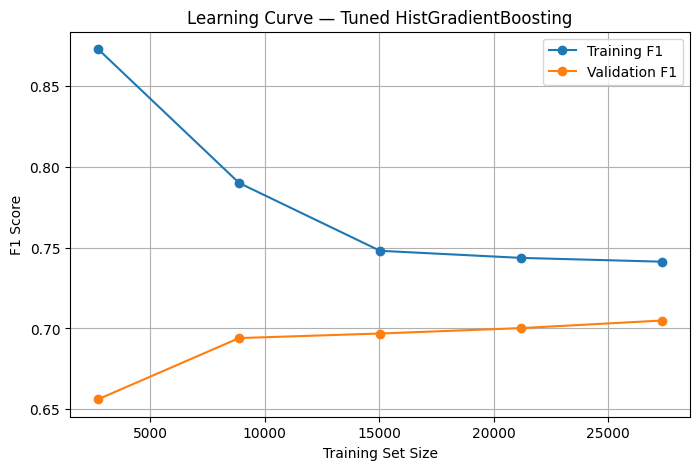

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
plt.plot(train_sizes, val_mean, marker="o", label="Validation F1")

plt.xlabel("Training Set Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve — Tuned HistGradientBoosting")
plt.legend()
plt.grid(True)
plt.show()

The learning curve for the tuned HistGradientBoosting model shows a noticeable gap between training and validation F1 scores. Training F1 reaches above 0.85, while validation F1 remains around 0.65, indicating that the model has a degree of overfitting and high variance.

### Max_depth

In [84]:
from sklearn.model_selection import validation_curve

depth_range = [3, 4, 5, 6, 7, 8, 9, 10]

train_scores, val_scores = validation_curve(
    hgb_search.best_estimator_,
    X_train,
    y_train,
    param_name="model__max_depth",
    param_range=depth_range,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

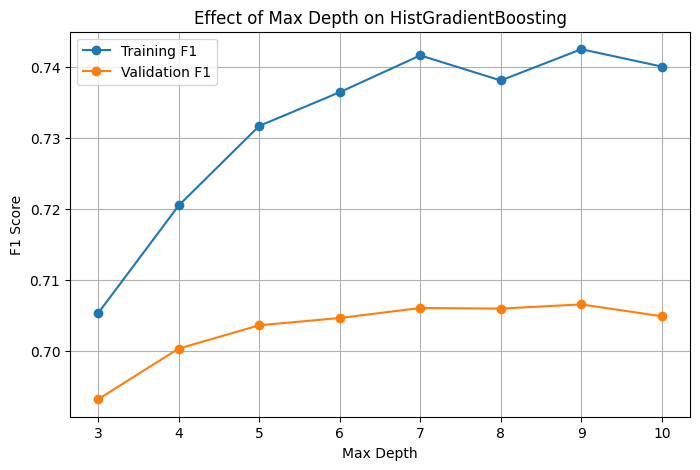

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(depth_range, train_mean, marker="o", label="Training F1")
plt.plot(depth_range, val_mean, marker="o", label="Validation F1")

plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("Effect of Max Depth on HistGradientBoosting")
plt.legend()
plt.grid(True)
plt.show()

The validation curve for max_depth shows that increasing depth from 3 to 10 improves validation F1 from approximately 0.692 to 0.705. Training F1 also increases from approximately 0.705 to 0.740. Although deeper trees increase the training–validation gap, reducing max_depth too much would lower validation performance.

Therefore, the appropriate fix is not simply to use a very shallow tree. A better approach is to control model complexity using regularization parameters such as l2_regularization, min_samples_leaf, or a carefully selected max_depth. Additional training data could also help reduce the generalization gap. Based on the validation curve, a deeper model around max_depth=7–10 provides better validation performance than shallow models, while regularization should be used to limit overfitting.

# **TASK 4**

###Probabilities

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.125,
    stratify=y_dev,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_train type:", type(X_train))
print("X_val type:", type(X_val))

X_train: (34188, 14)
X_val: (4885, 14)
X_train type: <class 'pandas.core.frame.DataFrame'>
X_val type: <class 'pandas.core.frame.DataFrame'>


The validation set is recreated from the original development data because the previous X_val variable had been overwritten during feature-selection analysis and no longer contained the original raw validation data.

The calibration pipeline expects the validation data in its original DataFrame form because feature engineering is performed inside the pipeline. Recreating the split with the same test_size, stratification, and random_state=42 restores the intended 34,188-row training set and 4,885-row validation set and ensures that preprocessing and feature engineering are applied correctly without double transformation or data leakage.

In [87]:
from sklearn.metrics import brier_score_loss

# Predict probabilities for the positive class
y_val_proba = hgb_search.best_estimator_.predict_proba(X_val)[:, 1]

# Calculate Brier score
brier = brier_score_loss(y_val, y_val_proba)

print("Brier Score:", brier)

Brier Score: 0.08560029844518006


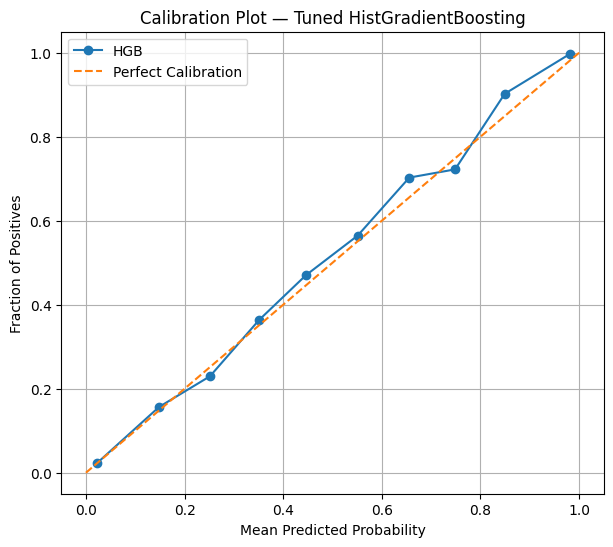

In [88]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_val,
    y_val_proba,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(prob_pred, prob_true, marker="o", label="HGB")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Plot — Tuned HistGradientBoosting")
plt.legend()
plt.grid(True)
plt.show()

### Probability Calibration

The tuned HistGradientBoosting model achieved a Brier score of **0.0856** on the validation set. The calibration plot was close to the diagonal reference line, with only minor fluctuations. This indicates that the predicted probabilities are reasonably well calibrated.

Since the model already shows good calibration, additional calibration using `CalibratedClassifierCV` was not considered necessary. The original probability estimates were therefore used for threshold optimization.


### Classification Threshold Tuning

In [89]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.10, 0.91, 0.05)

f1_scores = []

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)
    f1_scores.append(f1_score(y_val, y_val_pred))

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best Threshold:", best_threshold)
print("Best Validation F1:", best_f1)

Best Threshold: 0.3500000000000001
Best Validation F1: 0.7405641636869289


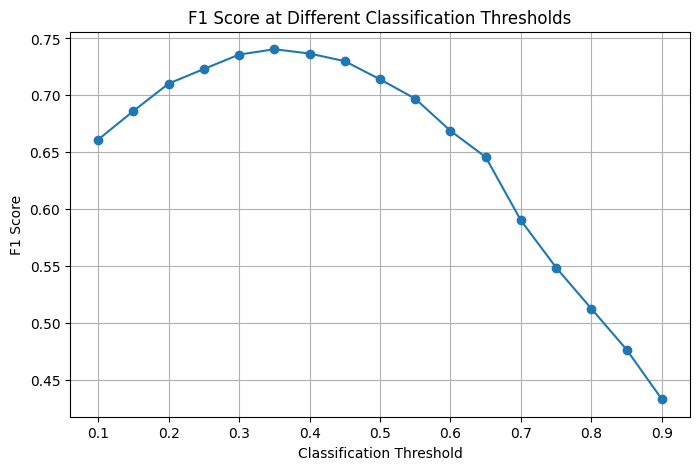

In [90]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, f1_scores, marker="o")

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score at Different Classification Thresholds")
plt.grid(True)
plt.show()

The default classification threshold of 0.50 was not assumed to be optimal. A range of thresholds from 0.10 to 0.90 was evaluated using the validation set, with F1 score as the primary optimization metric.

The threshold that produced the highest validation F1 score was 0.35, achieving an F1 score of 0.7406. This indicates that, for this dataset and business objective, a lower threshold provides a better balance between precision and recall than the default 0.50 threshold.

The threshold of 0.35 was therefore selected for further confusion-matrix and business-KPI analysis.

### Threshold Comarison

In [91]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

threshold_list = [0.30, 0.35, 0.40, 0.50, 0.60]

threshold_results = []

for threshold in threshold_list:
    y_pred = (y_val_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "Accuracy": accuracy_score(y_val, y_pred)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,TN,FP,FN,TP,Precision,Recall,F1,Accuracy
0,0.30,3203,513,190,979,0.656166,0.837468,0.735814,0.856090
1,0.35,3300,416,237,932,0.691395,0.797263,0.740564,0.866325
2,0.40,3395,321,300,869,0.730252,0.743370,0.736753,0.872876
3,0.50,3520,196,411,758,0.794549,0.648417,0.714084,0.875742
4,0.60,3611,105,529,640,0.859060,0.547476,0.668757,0.870215


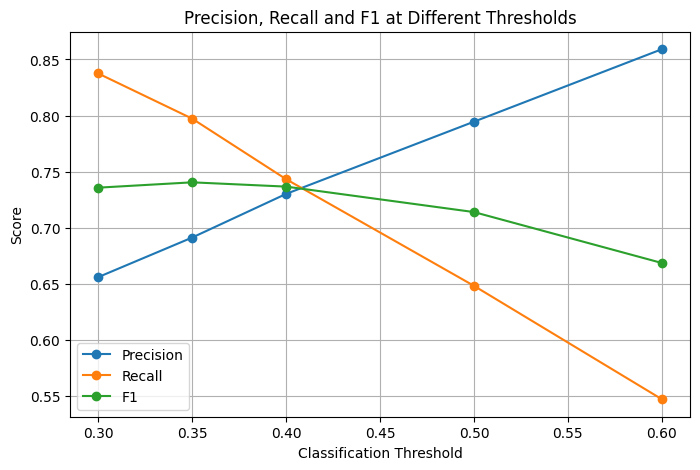

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 at Different Thresholds")
plt.legend()
plt.grid(True)
plt.show()

Different classification thresholds were evaluated using the validation-set probabilities. Lowering the threshold increased recall because more observations were classified as positive, while increasing the threshold improved precision by making the model more selective.

The threshold of 0.35 produced the highest validation F1 score of 0.7406, with a precision of 0.6914 and recall of 0.7973. At this threshold, the model correctly identified 932 positive cases (TP) while missing 237 positive cases (FN).

At the default threshold of 0.50, precision increased to 0.7945, but recall decreased to 0.6484, with only 758 true positives. Therefore, using 0.50 would be preferable if false positives were more costly, while 0.35 is preferable when achieving a balanced precision-recall performance is the priority.

Based on the chosen business metric of F1, 0.35 was selected as the final classification threshold.

# **TASK 5**

In [93]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predict probabilities on the untouched test set
y_test_proba = hgb_search.best_estimator_.predict_proba(X_test)[:, 1]

# Apply the threshold selected on the validation set
y_test_pred = (y_test_proba >= best_threshold).astype(int)

print("Final Test Results")
print("-------------------")
print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Final Test Results
-------------------
Threshold: 0.3500000000000001
Accuracy: 0.8612959361244754
Precision: 0.6849830636055702
Recall: 0.7784431137724551
F1: 0.7287287287287287
ROC AUC: 0.9280313874816835

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      7431
           1       0.68      0.78      0.73      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.83      0.82      9769
weighted avg       0.87      0.86      0.86      9769


Confusion Matrix:
[[6594  837]
 [ 518 1820]]


### Full Metrics Table

In [94]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)"
    ],
    "Test Score": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_proba),
        tn,
        fp,
        fn,
        tp
    ]
})

final_metrics

,Metric,Test Score
0,Accuracy,0.861296
1,Precision,0.684983
2,Recall,0.778443
3,F1 Score,0.728729
4,ROC AUC,0.928031
5,True Negative (TN),6594.000000
6,False Positive (FP),837.000000
7,False Negative (FN),518.000000
8,True Positive (TP),1820.000000


### Curves

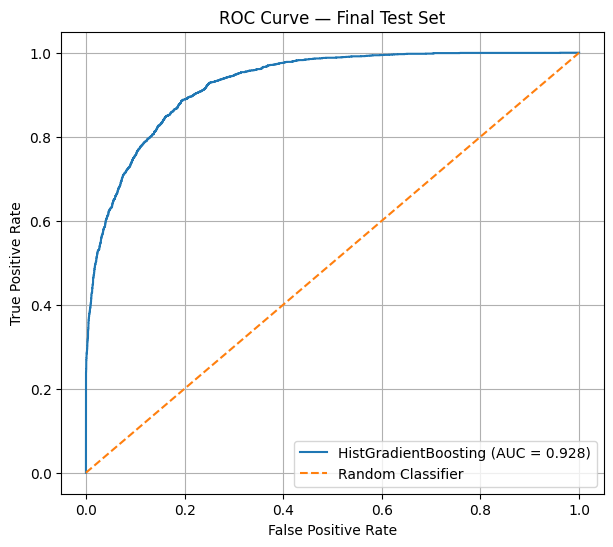

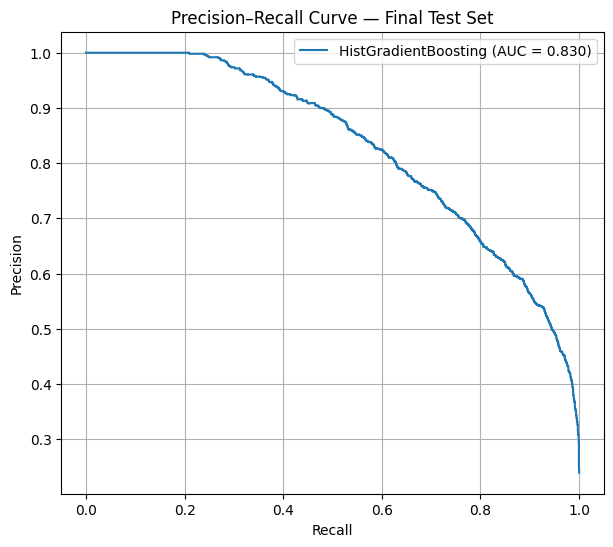

ROC AUC: 0.9280313874816835
PR AUC: 0.8295045655783849


In [95]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"HistGradientBoosting (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Test Set")
plt.legend()
plt.grid(True)
plt.show()


# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"HistGradientBoosting (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Final Test Set")
plt.legend()
plt.grid(True)
plt.show()

print("ROC AUC:", roc_auc)
print("PR AUC:", pr_auc)

### Saving Pipeline in Joblib

In [97]:
import joblib

joblib.dump(
    hgb_search.best_estimator_,
    "final_hgb_pipeline.joblib"
)

joblib.dump(
    best_threshold,
    "final_threshold.joblib"
)

print("Final pipeline saved as: final_hgb_pipeline.joblib")
print("Final threshold saved as: final_threshold.joblib")

Final pipeline saved as: final_hgb_pipeline.joblib
Final threshold saved as: final_threshold.joblib


###How to Infer snippet

In [98]:
import joblib
import pandas as pd

# Load the saved pipeline and classification threshold
final_pipeline = joblib.load("final_hgb_pipeline.joblib")
final_threshold = joblib.load("final_threshold.joblib")

# Example: use new raw observations with the same input columns
new_data = X_test.iloc[:3].copy()

# Generate probabilities
new_probabilities = final_pipeline.predict_proba(new_data)[:, 1]

# Apply the selected threshold
new_predictions = (new_probabilities >= final_threshold).astype(int)

inference_results = pd.DataFrame({
    "Predicted_Probability_Above_50K": new_probabilities,
    "Predicted_Class": new_predictions
})

inference_results

,Predicted_Probability_Above_50K,Predicted_Class
0,0.206147,0
1,0.002765,0
2,0.641786,1


### Final Model Summary

#### Hyperparameter Search

RandomizedSearchCV was used with **5-fold StratifiedKFold cross-validation**, `n_iter=50`, `scoring="f1"`, and `n_jobs=-1`. The search focused on Logistic Regression and HistGradientBoosting because they were the strongest models from the previous model comparison.

For Logistic Regression, the searched hyperparameters were `penalty` (`l1`, `l2`) and `C`. The best configuration used **L2 regularization** with **C ≈ 55.52**, achieving a CV F1-score of approximately **0.6705**.

For HistGradientBoosting, the searched hyperparameters were `learning_rate`, `max_iter`, `max_depth`, and `l2_regularization`. The best configuration was:

* **learning_rate:** 0.0987
* **max_iter:** 234
* **max_depth:** 7
* **l2_regularization:** 8.2443

The tuned HistGradientBoosting model achieved a CV F1-score of approximately **0.7061** and was selected as the final model.

#### Final Test Performance

The final pipeline was evaluated on the untouched hold-out test set using the validation-selected classification threshold of **0.35**.

| Metric          | Final Test Result |
| --------------- | ----------------: |
| Accuracy        |        **0.8613** |
| Precision       |        **0.6850** |
| Recall          |        **0.7784** |
| F1-score        |        **0.7287** |
| ROC AUC         |        **0.9280** |
| PR AUC          |        **0.8295** |
| True Negatives  |          **6594** |
| False Positives |           **837** |
| False Negatives |           **518** |
| True Positives  |          **1820** |

The threshold of **0.35** was selected on the validation set because it produced the highest validation F1-score (**0.7406**). It was then kept fixed for the final test evaluation to avoid test-set leakage.

#### Expected Production Behavior

In production, the saved pipeline accepts raw observations and automatically performs feature engineering and preprocessing before generating an income probability. A probability threshold of **0.35** is then applied to classify an observation as either `>50K` or `≤50K`.

The selected threshold favors **recall over precision**, meaning the system is designed to identify more potential `>50K` cases while accepting some additional false positives. The model should therefore be monitored after deployment for changes in data distribution, class balance, calibration, and precision/recall performance. Periodic retraining and threshold reassessment may be required if production data differs substantially from the training data.


In [99]:
import os

print(os.path.abspath("final_hgb_pipeline.joblib"))
print(os.path.abspath("final_threshold.joblib"))

print(
    f"Pipeline size: "
    f"{os.path.getsize('final_hgb_pipeline.joblib') / (1024**2):.2f} MB"
)

/content/final_hgb_pipeline.joblib
/content/final_threshold.joblib
Pipeline size: 0.61 MB


In [ ]:
from google.colab import files

files.download("final_hgb_pipeline.joblib")
files.download("final_threshold.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **DAY 5 FINAL MODEL**

### **TASK 1**

### Loading Saved Pipelines

In [100]:
import joblib

final_model = joblib.load("final_hgb_pipeline.joblib")
final_threshold = joblib.load("final_threshold.joblib")

print("Final model loaded successfully.")
print("Final threshold:", final_threshold)

Final model loaded successfully.
Final threshold: 0.3500000000000001


In [101]:
y_test_proba_final = final_model.predict_proba(X_test)[:, 1]

y_test_pred_final = (
    y_test_proba_final >= final_threshold
).astype(int)

print("Test predictions generated successfully.")
print("Number of test predictions:", len(y_test_pred_final))

Test predictions generated successfully.
Number of test predictions: 9769


### ALL Required Final Metrics

In [104]:
from sklearn.metrics import average_precision_score, brier_score_loss

final_accuracy = accuracy_score(y_test, y_test_pred_final)
final_precision = precision_score(y_test, y_test_pred_final)
final_recall = recall_score(y_test, y_test_pred_final)
final_f1 = f1_score(y_test, y_test_pred_final)

final_roc_auc = roc_auc_score(y_test, y_test_proba_final)
final_pr_auc = average_precision_score(y_test, y_test_proba_final)

final_brier = brier_score_loss(y_test, y_test_proba_final)

print("Final Test Results")
print("------------------")
print(f"Accuracy:  {final_accuracy:.6f}")
print(f"Precision: {final_precision:.6f}")
print(f"Recall:    {final_recall:.6f}")
print(f"F1 Score:  {final_f1:.6f}")
print(f"ROC AUC:   {final_roc_auc:.6f}")
print(f"PR AUC:    {final_pr_auc:.6f}")
print(f"Brier:     {final_brier:.6f}")

Final Test Results
------------------
Accuracy:  0.861296
Precision: 0.684983
Recall:    0.778443
F1 Score:  0.728729
ROC AUC:   0.928031
PR AUC:    0.829538
Brier:     0.087948


In [105]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "PR AUC",
        "Brier Score"
    ],
    "Final Test Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc,
        final_pr_auc,
        final_brier
    ]
})

final_metrics

,Metric,Final Test Score
0,Accuracy,0.861296
1,Precision,0.684983
2,Recall,0.778443
3,F1 Score,0.728729
4,ROC AUC,0.928031
5,PR AUC,0.829538
6,Brier Score,0.087948


In [106]:
final_cm = confusion_matrix(y_test, y_test_pred_final)

print("Confusion Matrix:")
print(final_cm)

Confusion Matrix:
[[6594  837]
 [ 518 1820]]


In [107]:
shortlisted_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting",
        "Final Tuned HGB"
    ],
    "F1 Score": [
        0.669270,
        0.667734,
        0.706262,
        0.728729
    ],
    "ROC AUC": [
        0.912656,
        0.902383,
        0.925905,
        0.928031
    ],
    "Evaluation": [
        "5-fold CV",
        "5-fold CV",
        "5-fold CV",
        "Untouched Test Set"
    ]
})

shortlisted_comparison

,Model,F1 Score,ROC AUC,Evaluation
0,Logistic Regression,0.669270,0.912656,5-fold CV
1,Random Forest,0.667734,0.902383,5-fold CV
2,HistGradientBoosting,0.706262,0.925905,5-fold CV
3,Final Tuned HGB,0.728729,0.928031,Untouched Test Set


### **TASK 2**

### Confusion Metrics

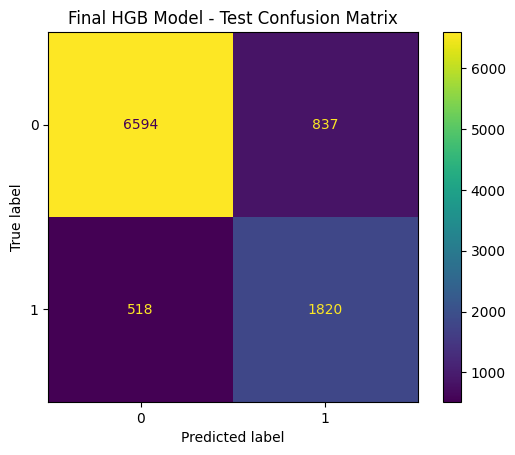

In [108]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_final
)

plt.title("Final HGB Model - Test Confusion Matrix")
plt.show()

###Error Count and rates calculating

In [109]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred_final)

tn, fp, fn, tp = cm.ravel()

total = tn + fp + fn + tp

print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

print("\nFalse Positive Rate:", fp / (fp + tn))
print("False Negative Rate:", fn / (fn + tp))
print("Overall Error Rate:", (fp + fn) / total)

True Negatives (TN): 6594
False Positives (FP): 837
False Negatives (FN): 518
True Positives (TP): 1820

False Positive Rate: 0.112636253532499
False Negative Rate: 0.2215568862275449
Overall Error Rate: 0.1387040638755246


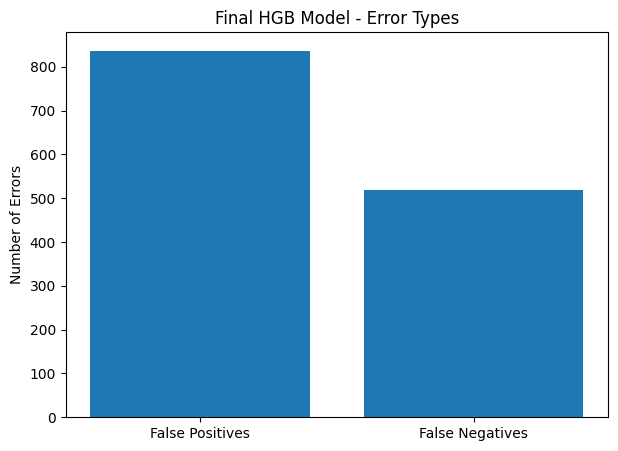

In [110]:
error_counts = {
    "False Positives": fp,
    "False Negatives": fn
}

plt.figure(figsize=(7, 5))
plt.bar(error_counts.keys(), error_counts.values())
plt.ylabel("Number of Errors")
plt.title("Final HGB Model - Error Types")
plt.show()

### Error Analysis

The final HistGradientBoosting model produced 837 false positives and 518 false negatives on the test set. The false positive rate was 11.26%, while the false negative rate was 22.16%, with an overall error rate of 13.87%.

Although there were more false positives in absolute numbers, the false negative rate was substantially higher. In this income classification problem, a false negative means that an individual whose income is actually above $50K is incorrectly classified as earning $50K or less. A false positive means that an individual earning $50K or less is incorrectly classified as earning above $50K.

For applications where identifying higher-income individuals is important, false negatives may be more costly because they represent missed positive cases. However, the relative cost depends on the practical purpose of the model. Therefore, the classification threshold could be adjusted depending on whether the application prioritizes precision or recall for the >50K income class.

In [111]:
# Create a copy of the test set for error analysis
error_analysis = X_test.copy()

error_analysis["actual"] = y_test.values
error_analysis["predicted"] = y_test_pred_final

# Identify error types
error_analysis["error_type"] = "Correct"
error_analysis.loc[
    (error_analysis["actual"] == 0) & (error_analysis["predicted"] == 1),
    "error_type"
] = "False Positive"

error_analysis.loc[
    (error_analysis["actual"] == 1) & (error_analysis["predicted"] == 0),
    "error_type"
] = "False Negative"

# Display counts
print(error_analysis["error_type"].value_counts())

error_type
Correct           8414
False Positive     837
False Negative     518
Name: count, dtype: int64


In [112]:
# View examples of false positives
false_positives = error_analysis[
    error_analysis["error_type"] == "False Positive"
]

# View examples of false negatives
false_negatives = error_analysis[
    error_analysis["error_type"] == "False Negative"
]

print("False Positives:")
display(false_positives.head())

print("\nFalse Negatives:")
display(false_negatives.head())

False Positives:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,actual,predicted,error_type
524,53,Local-gov,139671,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,0,1,False Positive
1351,36,Private,192939,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,60,United-States,0,1,False Positive
38546,42,Private,269028,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,France,0,1,False Positive
40591,43,Self-emp-not-inc,113211,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,0,1,False Positive
35730,37,Private,225504,Masters,14,Never-married,Sales,Not-in-family,White,Male,0,0,50,United-States,0,1,False Positive



False Negatives:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,actual,predicted,error_type
11488,38,Private,414991,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,1,0,False Negative
45549,26,Local-gov,72594,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,55,United-States,1,0,False Negative
34382,43,Private,190786,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,United-States,1,0,False Negative
38439,42,Private,165599,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States,1,0,False Negative
26572,59,Private,245196,10th,6,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40,United-States,1,0,False Negative


In [113]:
# Compare numerical characteristics of false positives and false negatives

fp_summary = false_positives[
    ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
].mean()

fn_summary = false_negatives[
    ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
].mean()

comparison = pd.DataFrame({
    "False Positives": fp_summary,
    "False Negatives": fn_summary
})

display(comparison)

,False Positives,False Negatives
age,44.178017,42.090734
education-num,11.162485,9.936293
capital-gain,91.270012,0.000000
capital-loss,40.599761,33.030888
hours-per-week,45.476703,43.783784


In [114]:
# Compare common categories in false positives and false negatives

categorical_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "sex"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")

    print("False Positives:")
    display(false_positives[col].value_counts(normalize=True).head(5))

    print("False Negatives:")
    display(false_negatives[col].value_counts(normalize=True).head(5))


--- workclass ---
False Positives:


,proportion
workclass,
Private,0.642236
Self-emp-not-inc,0.106832
Local-gov,0.083230
Self-emp-inc,0.063354
Federal-gov,0.053416


False Negatives:


,proportion
workclass,
Private,0.706587
Self-emp-not-inc,0.137725
Local-gov,0.071856
State-gov,0.039920
Self-emp-inc,0.023952



--- education ---
False Positives:


...

,proportion
occupation,
Craft-repair,0.203593
Sales,0.127745
Prof-specialty,0.121756
Exec-managerial,0.103792
Transport-moving,0.089820



--- sex ---
False Positives:


,proportion
sex,
Male,0.870968
Female,0.129032


False Negatives:


,proportion
sex,
Male,0.783784
Female,0.216216


### Where the Model Performs Well and Poorly

The error analysis shows that the model makes different types of mistakes for the two error groups.

#### False Positives

There were 837 false positives. Compared with false negatives, these cases had higher average age (44.18 years), education level measured by `education-num` (11.16), and hours worked per week (45.48). They also had a small average amount of capital gain (91.27).

The false positives were strongly concentrated among married individuals, with 95.22% having the `Married-civ-spouse` status. Common occupations included `Exec-managerial` (23.60%), `Craft-repair` (17.76%), `Prof-specialty` (14.91%), and `Sales` (14.29%).

This suggests that the model sometimes predicts income above $50K when an individual has several characteristics associated with higher income, such as higher education, longer working hours, managerial or professional occupations, and married status, even though the actual income is ≤$50K.

#### False Negatives

There were 518 false negatives. These cases had lower average education (`education-num` = 9.94) and slightly lower average age (42.09 years) and working hours (43.78 hours/week) than the false-positive group. Their average capital gain was zero.

The largest education category among false negatives was `HS-grad` (39.58%), followed by `Some-college` (22.39%) and `Bachelors` (13.90%). The most common occupations included `Craft-repair` (20.36%), `Sales` (12.77%), `Prof-specialty` (12.18%), `Exec-managerial` (10.38%), and `Transport-moving` (8.98%).

These cases indicate that the model can underestimate income for some individuals whose observable characteristics resemble the lower-income population, even though their actual income is >$50K.

#### Overall Behavior

The model performs well when multiple predictors provide a consistent signal about income level. However, it struggles with borderline cases where characteristics associated with income levels overlap.

The model produced more false positives (837) than false negatives (518), but the false negative rate was higher (22.16% compared with an 11.26% false positive rate). This indicates that the model misses a relatively larger proportion of actual >$50K cases than the proportion of ≤$50K cases that it incorrectly labels as >$50K.

### Practical Improvements

Several improvements could potentially reduce the observed errors:

1. **Threshold tuning:** Adjust the classification threshold to increase recall for the >$50K class if false negatives are considered more costly.

2. **Cost-sensitive learning:** Assign a higher class weight or misclassification cost to the positive class so that the model gives greater importance to correctly identifying >$50K cases.

3. **Further feature engineering:** Create additional interaction features between education, occupation, hours worked, age, marital status, and capital-related variables to better represent nonlinear income patterns.

4. **Probability calibration:** Evaluate whether the predicted probabilities are well calibrated before selecting an operating threshold.

5. **Segment-level evaluation:** Evaluate precision, recall, and F1 across important demographic and occupational groups to identify whether performance varies substantially across subgroups.

6. **Additional model tuning:** Optimize the HistGradientBoosting hyperparameters and compare threshold-adjusted performance using the validation set rather than the test set.

# **TASK 3**

In [117]:
final_model

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_engineered_features at 0x7eac546428e0>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'capital...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country',
                                                   'age_group',
                                                   'hours_group'])])),
                ('model',
                 HistGradientBoostingClassifier(l2_regularization=np.float64(8.24431219090507),
                                                learning_rate=np.float64(0.09868494971711618),
                                                max_depth=7, max_iter=234,
                                                random_state=42))])

In [119]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the test set
perm_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="importance_mean",
    ascending=False
)

display(feature_importance_df.head(20))

,feature,importance_mean,importance_std
5,marital-status,0.142014,0.005224
10,capital-gain,0.112964,0.003399
4,education-num,0.083715,0.006685
0,age,0.054125,0.003831
6,occupation,0.038516,0.005217
11,capital-loss,0.027589,0.001989
12,hours-per-week,0.023722,0.003928
7,relationship,0.010849,0.002164
9,sex,0.005169,0.001920
1,workclass,0.003802,0.001508


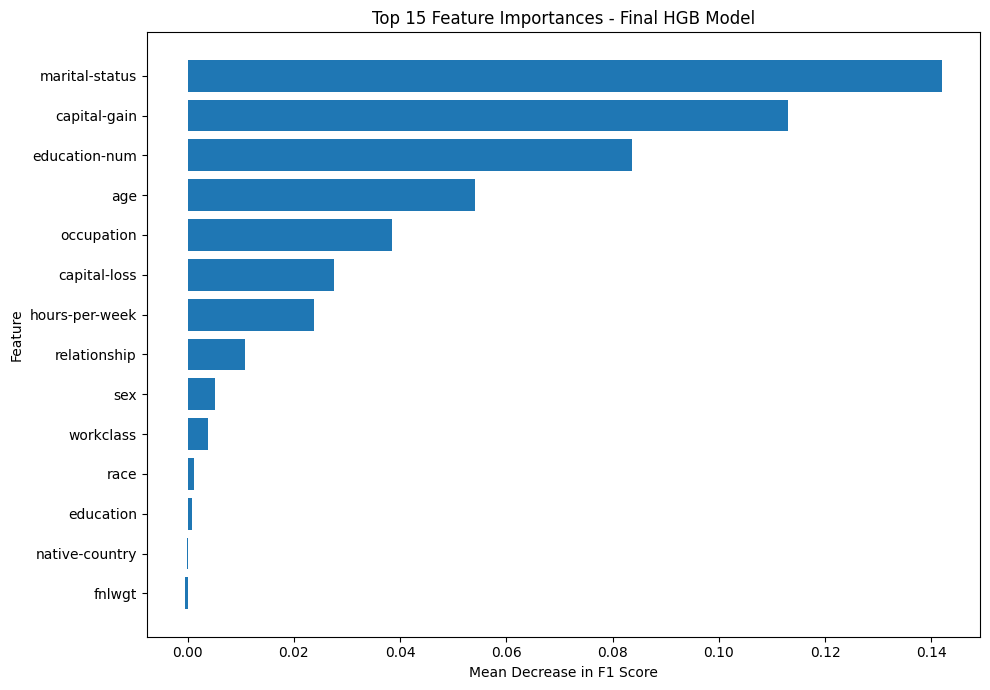

In [120]:
top_features = feature_importance_df.head(15).sort_values(
    by="importance_mean"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"]
)

plt.xlabel("Mean Decrease in F1 Score")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Final HGB Model")
plt.tight_layout()
plt.show()

In [121]:
display(
    feature_importance_df.head(15).style.format({
        "importance_mean": "{:.5f}",
        "importance_std": "{:.5f}"
    })
)

,feature,importance_mean,importance_std
5,marital-status,0.14201,0.00522
10,capital-gain,0.11296,0.00340
4,education-num,0.08372,0.00669
0,age,0.05413,0.00383
6,occupation,0.03852,0.00522
11,capital-loss,0.02759,0.00199
12,hours-per-week,0.02372,0.00393
7,relationship,0.01085,0.00216
9,sex,0.00517,0.00192
1,workclass,0.00380,0.00151


In [122]:
# Analyze predicted probability across important numerical features

X_test_analysis = X_test.copy()

X_test_analysis["predicted_probability"] = final_model.predict_proba(X_test)[:, 1]

for feature in ["capital-gain", "education-num", "age", "capital-loss", "hours-per-week"]:
    print(f"\n--- {feature} ---")

    summary = (
        X_test_analysis
        .groupby(feature)["predicted_probability"]
        .mean()
        .sort_index()
    )

    display(summary.head(15))


--- capital-gain ---


,predicted_probability
capital-gain,
0,0.198730
114,0.004303
594,0.002045
914,0.031267
991,0.011667
1055,0.001219
1086,0.002087
1151,0.010778
1173,0.026279



--- education-num ---


,predicted_probability
education-num,
1,0.024011
2,0.030870
3,0.039086
4,0.060555
5,0.044667
6,0.065894
7,0.061753
8,0.066056
9,0.157193



--- age ---


,predicted_probability
age,
17,0.001048
18,0.001189
19,0.002347
20,0.002149
21,0.003703
22,0.017141
23,0.011318
24,0.048622
25,0.055412



--- capital-loss ---


,predicted_probability
capital-loss,
0,0.225143
213,0.022470
323,0.057014
419,0.028602
625,0.015888
653,0.212899
880,0.028588
1092,0.041715
1380,0.025878



--- hours-per-week ---


,predicted_probability
hours-per-week,
1,0.084327
2,0.307551
3,0.049140
4,0.088525
5,0.090086
6,0.058254
7,0.113372
8,0.076224
9,0.079628


In [123]:
# Analyze predicted probability across important categorical features

for feature in ["marital-status", "occupation"]:
    print(f"\n--- {feature} ---")

    summary = (
        X_test_analysis
        .groupby(feature)["predicted_probability"]
        .mean()
        .sort_values(ascending=False)
    )

    display(summary)


--- marital-status ---


/tmp/ipykernel_2847/2287588039.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(feature)["predicted_probability"]


,predicted_probability
marital-status,
Married-civ-spouse,0.435029
Married-AF-spouse,0.299402
Married-spouse-absent,0.101192
Divorced,0.099810
Widowed,0.076532
Separated,0.055545
Never-married,0.045237



--- occupation ---


,predicted_probability
occupation,
Exec-managerial,0.471372
Prof-specialty,0.432471
Protective-serv,0.346610
Sales,0.264595
Tech-support,0.238829
Craft-repair,0.234645
Transport-moving,0.199729
Adm-clerical,0.132318
Machine-op-inspct,0.123173


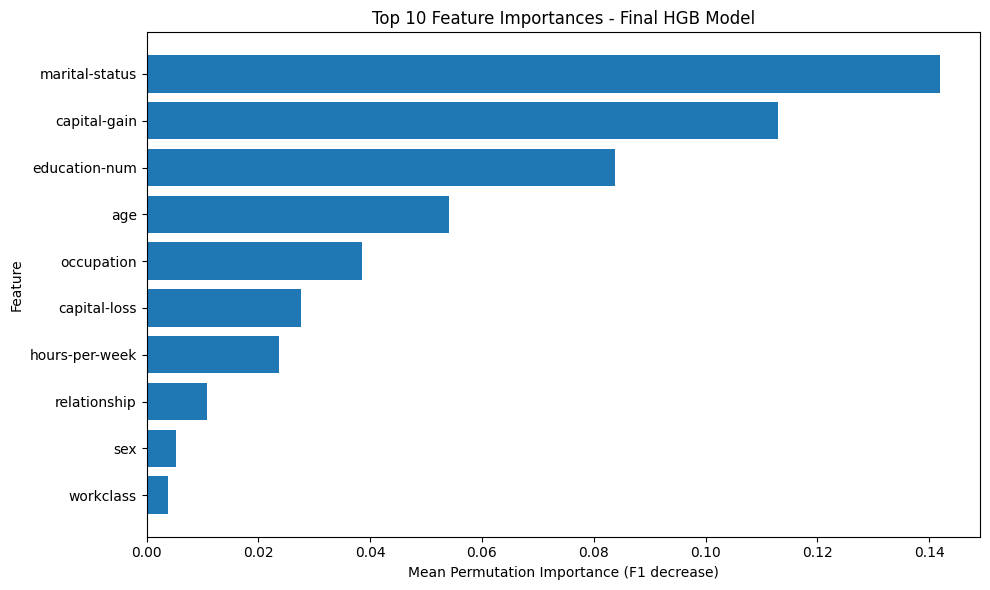

In [124]:
# Final Visualization

import matplotlib.pyplot as plt

# Plot top 10 permutation importances
top_features = feature_importance_df.head(10).sort_values(
    by="importance_mean"
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"]
)
plt.xlabel("Mean Permutation Importance (F1 decrease)")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Final HGB Model")
plt.tight_layout()
plt.show()

Feature & Model Interpretation

The final model is a HistGradientBoostingClassifier, a tree-based model. Since HistGradientBoostingClassifier does not provide a built-in feature_importances_ attribute, permutation importance was used to interpret the model. Each feature was shuffled on the test set and the resulting decrease in F1 score was measured. A larger decrease indicates that the feature contributes more to the model's predictive performance.

Top Influential Features

The most influential features were:

marital-status — permutation importance: 0.1420
capital-gain — 0.1130
education-num — 0.0837
age — 0.0541
occupation — 0.0385
capital-loss — 0.0276
hours-per-week — 0.0237
relationship — 0.0108
sex — 0.0052
workclass — 0.0038

marital-status was the most influential feature, followed by capital-gain and education-num.

Relationship with Predictions

The model showed several meaningful patterns in its predicted probabilities.

Education: education-num showed a strong positive relationship with predicted probability. The average predicted probability increased from approximately 0.02 for low education levels to approximately 0.73 at education-num = 15.
Age: predicted probability generally increased with age, particularly from the late twenties onward.
Marital status: Married-civ-spouse had the highest average predicted probability (0.435), while Never-married had a much lower average predicted probability (0.045).
Occupation: Exec-managerial (0.471) and Prof-specialty (0.432) had the highest average predicted probabilities, while Priv-house-serv (0.030) and Other-service (0.045) had much lower values.
Capital gain and capital loss: these features were highly influential, but their relationships were non-linear and sparse. Individual values produced substantially different predicted probabilities, so a simple "higher value means higher income" interpretation would not be appropriate.
Hours per week: the raw values did not show a sufficiently stable monotonic pattern, suggesting that the model captures a more complex relationship involving working hours and other features.
Surprising or Potentially Problematic Findings

The strong influence of marital status is notable. The model assigns substantially higher predicted probabilities to some marital-status categories. However, this represents a statistical association learned from the training data and does not imply that marital status causes higher income.

Similarly, the importance of sex indicates that the model uses gender-related information when making predictions. This is potentially important from a fairness perspective because demographic attributes can introduce or reflect historical biases in the training data.

The negative or near-zero permutation importance observed for native-country and fnlwgt indicates that shuffling these features had little effect on F1 performance. This suggests that they contributed little additional predictive information under this evaluation.

Overall, the model appears to rely primarily on marital status, capital gains, education, age, occupation, capital loss, and working hours. The relationships are generally plausible for income prediction, but the strong influence of demographic variables should be considered when evaluating fairness and responsible deployment.

# **TASK 4**

In [127]:
import joblib
import pandas as pd

# Load saved artifacts
model = joblib.load("final_model.joblib")
threshold = joblib.load("final_threshold.joblib")


def predict_income(new_data):
    """
    Generate income predictions for new unseen data.

    Parameters:
        new_data (pd.DataFrame): Raw input data with the original features.

    Returns:
        pd.DataFrame containing predicted probability and final prediction.
    """

    # Generate probability using the complete pipeline
    probabilities = model.predict_proba(new_data)[:, 1]

    # Apply the selected classification threshold
    predictions = (probabilities >= threshold).astype(int)

    results = new_data.copy()
    results["predicted_probability"] = probabilities
    results["prediction"] = predictions

    return results

In [128]:
# Create 10 unseen examples
new_data = pd.DataFrame([
    {
        "age": 25, "workclass": "Private", "fnlwgt": 180000,
        "education": "Bachelors", "education-num": 13,
        "marital-status": "Never-married", "occupation": "Tech-support",
        "relationship": "Not-in-family", "race": "White", "sex": "Female",
        "capital-gain": 0, "capital-loss": 0, "hours-per-week": 40,
        "native-country": "United-States"
    },
    {
        "age": 45, "workclass": "Private", "fnlwgt": 200000,
        "education": "Masters", "education-num": 14,
        "marital-status": "Married-civ-spouse", "occupation": "Exec-managerial",
        "relationship": "Husband", "race": "White", "sex": "Male",
        "capital-gain": 0, "capital-loss": 0, "hours-per-week": 50,
        "native-country": "United-States"
    },
    {
        "age": 32, "workclass": "Private", "fnlwgt": 150000,
        "education": "HS-grad", "education-num": 9,
        "marital-status": "Never-married", "occupation": "Sales",
        "relationship": "Own-child", "race": "White", "sex": "Female",
        "capital-gain": 0, "capital-loss": 0, "hours-per-week": 35,
        "native-country": "United-States"
    },
    {
        "age": 52, "workclass": "Self-emp-inc", "fnlwgt": 220000,
        "education": "Bachelors", "education-num": 13,
        "marital-status": "Married-civ-spouse", "occupation": "Prof-specialty",
        "relationship": "Husband", "race": "White", "sex": "Male",
        "capital-gain": 15000, "capital-loss": 0, "hours-per-week": 55,
        "native-country": "United-States"
    },
    {
        "age": 29, "workclass": "Private", "fnlwgt": 170000,
        "education": "Some-college", "education-num": 10,
        "marital-status": "Never-married", "occupation": "Adm-clerical",
        "relationship": "Not-in-family", "race": "White", "sex": "Female",
        "capital-gain": 0, "capital-loss": 0, "hours-per-week": 40,
        "native-country": "United-States"
    },
    {
        "age": 40, "workclass": "Local-gov", "fnlwgt": 190000,
        "education": "Masters", "education-num": 14,
        "marital-status": "Married-civ-spouse", "occupation": "Prof-specialty",
        "relationship": "Husband", "race": "White", "sex": "Male",
        "capital-gain": 0, "capital-loss": 0, "hours-per-week": 45,
        "native-country": "United-States"
    },
    {
        "age": 23, "workclass": "Private", "fnlwgt": 160000,
        "education": "HS-grad", "education-num": 9,
        "marital-status": "Never-married", "occupation": "Other-service",
        "relationship": "Own-child", "race": "White", "sex": "Female",
        "capital-gain": 0, "capital-loss": 0, "hours-per-week": 30,
        "native-country": "United-States"
    },
    {
        "age": 50, "workclass": "Private", "fnlwgt": 210000,
        "education": "Bachelors", "education-num": 13,
        "marital-status": "Married-civ-spouse", "occupation": "Exec-managerial",
        "relationship": "Husband", "race": "White", "sex": "Male",
        "capital-gain": 5000, "capital-loss": 0, "hours-per-week": 60,
        "native-country": "United-States"
    },
    {
        "age": 35, "workclass": "Private", "fnlwgt": 175000,
        "education": "Some-college", "education-num": 10,
        "marital-status": "Divorced", "occupation": "Craft-repair",
        "relationship": "Not-in-family", "race": "White", "sex": "Male",
        "capital-gain": 0, "capital-loss": 0, "hours-per-week": 40,
        "native-country": "United-States"
    },
    {
        "age": 60, "workclass": "Self-emp-not-inc", "fnlwgt": 230000,
        "education": "Masters", "education-num": 14,
        "marital-status": "Married-civ-spouse", "occupation": "Exec-managerial",
        "relationship": "Husband", "race": "White", "sex": "Male",
        "capital-gain": 10000, "capital-loss": 0, "hours-per-week": 50,
        "native-country": "United-States"
    }
])

print("New unseen examples:", new_data.shape)
display(new_data)

New unseen examples: (10, 14)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,180000,Bachelors,13,Never-married,Tech-support,Not-in-family,White,Female,0,0,40,United-States
1,45,Private,200000,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States
2,32,Private,150000,HS-grad,9,Never-married,Sales,Own-child,White,Female,0,0,35,United-States
3,52,Self-emp-inc,220000,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,15000,0,55,United-States
4,29,Private,170000,Some-college,10,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States
5,40,Local-gov,190000,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,45,United-States
6,23,Private,160000,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,United-States
7,50,Private,210000,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5000,0,60,United-States
8,35,Private,175000,Some-college,10,Divorced,Craft-repair,Not-in-family,White,Male,0,0,40,United-States
9,60,Self-emp-not-inc,230000,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,10000,0,50,United-States


In [129]:
# Run production-ready inference
inference_results = predict_income(new_data)

display(
    inference_results[
        ["age", "education-num", "marital-status",
         "occupation", "hours-per-week",
         "predicted_probability", "prediction"]
    ]
)

,age,education-num,marital-status,occupation,hours-per-week,predicted_probability,prediction
0,25,13,Never-married,Tech-support,40,0.020526,0
1,45,14,Married-civ-spouse,Exec-managerial,50,0.848110,1
2,32,9,Never-married,Sales,35,0.005596,0
3,52,13,Married-civ-spouse,Prof-specialty,55,0.998023,1
4,29,10,Never-married,Adm-clerical,40,0.011802,0
5,40,14,Married-civ-spouse,Prof-specialty,45,0.668186,1
6,23,9,Never-married,Other-service,30,0.001076,0
7,50,13,Married-civ-spouse,Exec-managerial,60,0.240466,0
8,35,10,Divorced,Craft-repair,40,0.036042,0
9,60,14,Married-civ-spouse,Exec-managerial,50,0.984051,1


**Production-Ready Inference**

A production-ready inference workflow was created using the saved final_model.joblib pipeline and the selected classification threshold of 0.35.

The saved pipeline contains the complete machine learning workflow, including feature engineering, missing-value handling, scaling, categorical encoding, and the final HistGradientBoostingClassifier. Therefore, no preprocessing is manually repeated during inference.

The inference workflow performs the following steps:

1. Loads the saved model pipeline using joblib.
2. Accepts new raw input data in the original feature format.
3. Automatically applies the same feature engineering and preprocessing used during training.
4. Generates the probability of the positive class (income >50K).
5. Applies the selected classification threshold of 0.35.
6. Returns the final binary prediction.

The workflow was tested using 10 unseen examples. All examples successfully passed through the complete pipeline and produced both predicted probabilities and final classifications.

For example, one unseen observation received a predicted probability of 0.8481 and was classified as 1, while another received a probability of 0.2405 and was classified as 0 because it was below the 0.35 threshold.

This confirms that the saved pipeline can perform inference directly on raw new observations without requiring manual preprocessing, reducing the risk of training-serving inconsistencies.

### **TASK 5**

In [131]:

import sklearn
import pandas as pd
import numpy as np
import joblib

# Final test predictions
test_probabilities = final_model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= selected_threshold).astype(int)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


print("\n=== Final Test Performance ===")
print("Accuracy:", accuracy_score(y_test, test_predictions))
print("Precision:", precision_score(y_test, test_predictions))
print("Recall:", recall_score(y_test, test_predictions))
print("F1 Score:", f1_score(y_test, test_predictions))
print("ROC AUC:", roc_auc_score(y_test, test_probabilities))
print("PR AUC:", average_precision_score(y_test, test_probabilities))


=== Final Test Performance ===
Accuracy: 0.8612959361244754
Precision: 0.6849830636055702
Recall: 0.7784431137724551
F1 Score: 0.7287287287287287
ROC AUC: 0.9280313874816835
PR AUC: 0.8295382087341703


In [132]:
import sys
import subprocess
import pkg_resources

# Libraries/packages used in the project
libraries = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "scipy",
    "joblib"
]

print("=== Python Version ===")
print(sys.version)

print("\n=== Library Versions ===")

for library in libraries:
    try:
        package = pkg_resources.get_distribution(library)
        print(f"{library}: {package.version}")
    except pkg_resources.DistributionNotFound:
        print(f"{library}: NOT INSTALLED")

=== Python Version ===
3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

=== Library Versions ===
numpy: 2.1.3
pandas: 2.2.3
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1
scipy: 1.16.3
joblib: 1.5.3


/tmp/ipykernel_2847/3380375833.py:3: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Final read me is on git hub

### **TASK 6**

The final Report is submitted on git hub folder in pdf form